# Customer Churn — Feature Engineering & Statistical Analysis
**Owner:** Mohamed Mohy
**Notebook:** 02_mohy_feature_engineering.ipynb


  ARTIFACT CONTRACT                                           
  Notebook: 02_mohy_feature_engineering.ipynb                

  INPUT:      data/cleaned/cleaned_telco.csv  (7,043 rows × 20 columns)       
  OUTPUTS:    data/cleaned/processed_telco.csv              
              data/summaries/                             
              assets/plots/features/                           
  NEXT:       03_mahmoud_modeling_baseline.ipynb           


**Objective:** This notebook takes the cleaned Telco dataset from Phase 1 and prepares it for machine learning. It performs statistical analysis to identify significant features, engineers 5 new features to improve model performance, encodes all categorical columns to numeric, and exports a fully model-ready dataset.

## Inputs & Expected Outputs

**Inputs:**
- `data/cleaned/cleaned_telco.csv` — 7,043 rows × 20 columns, from Moaz
- NOTE: Churn Label is ALREADY int64 (0/1) — do NOT re-encode target
- NOTE: Total Charges is ALREADY float64 — no dtype fix needed

**Outputs:**
- `data/cleaned/processed_telco.csv` — fully numeric, model-ready
- `data/summaries/statistical_tests.csv` — chi-square and Mann-Whitney results
- `data/summaries/selected_features.csv` — recommended feature list
- `data/summaries/feature_engineering_log.csv` — new features documentation
- `assets/plots/features/*.png` — visualizations

>  MULTICOLLINEARITY WARNING: Tenure Months and Total Charges have r=0.825 correlation. Both will be kept in the export but flagged for Mohamed Mahmoud to handle during model pipeline construction.

## 1. Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
from scipy.stats import chi2_contingency, mannwhitneyu
from sklearn.ensemble import RandomForestClassifier
import warnings

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Configuration

In [5]:
# ── Paths ────────────────────────────────────────────
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    candidate_root = PROJECT_ROOT.parent
    if (candidate_root / "data").exists() and (candidate_root / "notebooks").exists():
        PROJECT_ROOT = candidate_root

if not (PROJECT_ROOT / "data").exists():
    raise FileNotFoundError("Could not locate project root containing the data directory.")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from runtime_audit_utils import backup_if_overwriting, record_regeneration_step

CLEANED_DATA_PATH   = PROJECT_ROOT / "data/cleaned/cleaned_telco.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data/cleaned/processed_telco.csv"
SUMMARIES_PATH      = PROJECT_ROOT / "data/summaries"
PLOTS_PATH          = PROJECT_ROOT / "assets/plots/features"
REPORTS_PATH        = PROJECT_ROOT / "reports"

# ── Constants ─────────────────────────────────────────
RANDOM_STATE        = 42
TARGET_COLUMN       = "Churn Label"
EXPECTED_INPUT_ROWS = 7043
EXPECTED_INPUT_COLS = 20

# ── Feature lists for encoding ────────────────────────
BINARY_YES_NO_COLS = [
    "Senior Citizen", "Partner", "Dependents",
    "Phone Service", "Paperless Billing"
]

INTERNET_SERVICE_ADD_ONS = [
    "Online Security", "Online Backup", "Device Protection",
    "Tech Support", "Streaming TV", "Streaming Movies"
]

OHE_COLS = ["Internet Service", "Payment Method"]

# ── Feature engineering constants ─────────────────────
TENURE_BINS   = [0, 12, 24, 48, 72]
TENURE_LABELS = ["New", "Early", "Mid", "Long"]

# Create output directories
for p in [PROCESSED_DATA_PATH.parent, SUMMARIES_PATH, PLOTS_PATH, REPORTS_PATH]:
    p.mkdir(parents=True, exist_ok=True)

print("Configuration complete. All directories created.")

Configuration complete. All directories created.


## 3. Data Loading

In [6]:
df = pd.read_csv(CLEANED_DATA_PATH)
print(f"Shape: {df.shape}")
print(f"\nDtype summary:\n{df.dtypes.value_counts()}")
display(df.head(3))

Shape: (7043, 20)

Dtype summary:
object     16
int64       2
float64     2
Name: count, dtype: int64


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1


### GATE 1 — Input Schema Validation
_This notebook CANNOT continue until all checks pass._

In [7]:
if len(df) == EXPECTED_INPUT_ROWS:
    print(f"GATE 1.1 PASS: {len(df)} rows loaded.")
else:
    raise ValueError(f"GATE 1.1 FAIL: Expected {EXPECTED_INPUT_ROWS}, got {len(df)}.")

if len(df.columns) == EXPECTED_INPUT_COLS:
    print(f"GATE 1.2 PASS: {len(df.columns)} columns confirmed.")
else:
    raise ValueError(f"GATE 1.2 FAIL: Expected {EXPECTED_INPUT_COLS} columns, got {len(df.columns)}.")

if TARGET_COLUMN in df.columns and pd.api.types.is_numeric_dtype(df[TARGET_COLUMN]):
    print(f"GATE 1.3 PASS: '{TARGET_COLUMN}' is numeric (int64). No re-encoding needed.")
else:
    raise ValueError(f"GATE 1.3 FAIL: Target column missing or wrong dtype.")

null_counts = df.isnull().sum()
unexpected_nulls = null_counts[(null_counts > 0) & (null_counts.index != 'Total Charges')]
if unexpected_nulls.empty:
    print(f"GATE 1.4 PASS: Only {int(null_counts['Total Charges'])} expected Total Charges nulls remain for training-only pipeline imputation.")
else:
    raise ValueError(f"GATE 1.4 FAIL: Unexpected nulls found: {unexpected_nulls.to_dict()}. Re-run Phase 1.")

leakage = ["Churn Score", "Churn Value", "Churn Reason", "CLTV"]
found = [c for c in leakage if c in df.columns]
if not found:
    print(f"GATE 1.5 PASS: No leakage columns detected.")
else:
    raise ValueError(f"GATE 1.5 FAIL: Leakage columns found: {found}. STOP.")

print("\nGATE 1 COMPLETE — Input is valid. Safe to continue.")
print(f"   Churn rate: {df[TARGET_COLUMN].mean()*100:.1f}%")
print(f"   Class 0 (Not Churned): {(df[TARGET_COLUMN]==0).sum()}")
print(f"   Class 1 (Churned):     {(df[TARGET_COLUMN]==1).sum()}")

GATE 1.1 PASS: 7043 rows loaded.
GATE 1.2 PASS: 20 columns confirmed.
GATE 1.3 PASS: 'Churn Label' is numeric (int64). No re-encoding needed.
GATE 1.4 PASS: Only 11 expected Total Charges nulls remain for training-only pipeline imputation.
GATE 1.5 PASS: No leakage columns detected.

GATE 1 COMPLETE — Input is valid. Safe to continue.
   Churn rate: 26.5%
   Class 0 (Not Churned): 5174
   Class 1 (Churned):     1869


## 4. Statistical Analysis
We run formal statistical tests to confirm which features are significantly associated with churn. This guides feature selection.
- **Chi-Square test**: for categorical features
- **Mann-Whitney U test**: for numeric features (non-parametric, no normality assumption required)

> **WARNING**: Statistical analysis in this notebook is exploratory only. Final feature validation must occur AFTER train/test split during Phase 3 modeling.

### 4.1 Chi-Square Tests — Categorical Features

In [8]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

chi_results = []
for col in cat_cols:
    ct = pd.crosstab(df[col], df[TARGET_COLUMN])
    chi2, p, dof, _ = chi2_contingency(ct)
    chi_results.append({
        'Feature':     col,
        'Chi2_Stat':   round(chi2, 2),
        'p_value':     round(p, 6),
        'Degrees_of_Freedom': dof,
        'Significant': 'YES' if p < 0.05 else 'NO'
    })

chi_df = pd.DataFrame(chi_results).sort_values('p_value').reset_index(drop=True)

print("=== Chi-Square Test Results ===")
print(f"Significant (p < 0.05): {(chi_df['Significant']=='YES').sum()} features")
print(f"NOT significant:        {(chi_df['Significant']=='NO').sum()} features")
print()
display(chi_df)

print("\nNOT significant (candidates for removal):")
not_sig = chi_df[chi_df['Significant']=='NO']['Feature'].tolist()
for f in not_sig:
    print(f"   → {f}")

=== Chi-Square Test Results ===
Significant (p < 0.05): 14 features
NOT significant:        2 features



,Feature,Chi2_Stat,p_value,Degrees_of_Freedom,Significant
0,Senior Citizen,159.43,0.000000,1,YES
1,Partner,158.73,0.000000,1,YES
2,Dependents,433.73,0.000000,1,YES
3,Online Security,850.00,0.000000,2,YES
4,Internet Service,732.31,0.000000,2,YES
5,Tech Support,828.20,0.000000,2,YES
6,Device Protection,558.42,0.000000,2,YES
7,Online Backup,601.81,0.000000,2,YES
8,Streaming Movies,375.66,0.000000,2,YES
9,Contract,1184.60,0.000000,2,YES



NOT significant (candidates for removal):
   → Phone Service
   → Gender


### 4.2 Mann-Whitney U Tests — Numeric Features

In [10]:
num_cols = ['Tenure Months', 'Monthly Charges', 'Total Charges']

mwu_results = []
for col in num_cols:
    group0 = df[df[TARGET_COLUMN] == 0][col]
    group1 = df[df[TARGET_COLUMN] == 1][col]
    stat, p = mannwhitneyu(group0, group1, alternative='two-sided')
    mwu_results.append({
        'Feature':        col,
        'Mean_NotChurned': round(group0.mean(), 2),
        'Mean_Churned':    round(group1.mean(), 2),
        'MWU_Statistic':   round(stat, 2),
        'p_value':         round(p, 6),
        'Significant':    'YES' if p < 0.05 else 'NO'
    })

mwu_df = pd.DataFrame(mwu_results)
print("Mann-Whitney U Test Results")
display(mwu_df)

print()
print("MULTICOLLINEARITY CHECK:")
corr_matrix = df[num_cols].corr()
print(corr_matrix.round(3).to_string())
print()
tenure_total_corr = df['Tenure Months'].corr(df['Total Charges'])
print(f"Tenure Months ↔ Total Charges: r = {tenure_total_corr:.3f}")
print("   → HIGH multicollinearity (r > 0.80). Flagged for Mohamed Mahmoud.")

Mann-Whitney U Test Results


,Feature,Mean_NotChurned,Mean_Churned,MWU_Statistic,p_value,Significant
0,Tenure Months,37.57,17.98,7154668.0,0.0,YES
1,Monthly Charges,61.27,74.44,3667080.5,0.0,YES
2,Total Charges,2555.34,1531.80,NaN,NaN,NO



MULTICOLLINEARITY CHECK:
                 Tenure Months  Monthly Charges  Total Charges
Tenure Months            1.000            0.248          0.826
Monthly Charges          0.248            1.000          0.651
Total Charges            0.826            0.651          1.000

Tenure Months ↔ Total Charges: r = 0.826
   → HIGH multicollinearity (r > 0.80). Flagged for Mohamed Mahmoud.


### 4.3 Statistical Summary & Export

In [12]:
combined = pd.concat([
    chi_df.assign(Test_Type='Chi-Square')[
        ['Feature', 'Test_Type', 'p_value', 'Significant']
    ],
    mwu_df.assign(Test_Type='Mann-Whitney')[
        ['Feature', 'Test_Type', 'p_value', 'Significant']
    ]
], ignore_index=True).sort_values('p_value').reset_index(drop=True)

combined.to_csv(SUMMARIES_PATH / "statistical_tests.csv", index=False, encoding='utf-8')
print(f"Saved: {SUMMARIES_PATH / 'statistical_tests.csv'}")
print()
print("=== Features NOT significant (p ≥ 0.05) ===")
not_sig_all = combined[combined['Significant'] == 'NO']
if len(not_sig_all) == 0:
    print("All features are significant.")
else:
    display(not_sig_all)
    print("→ These features will be flagged in feature selection (Section 7).")

Saved: c:\Users\momoh\Downloads\Customer-Churn-Prediction-and-Analysis-Project-main\data\summaries\statistical_tests.csv

=== Features NOT significant (p ≥ 0.05) ===


,Feature,Test_Type,p_value,Significant
16,Phone Service,Chi-Square,0.338783,NO
17,Gender,Chi-Square,0.486579,NO
18,Total Charges,Mann-Whitney,NaN,NO


→ These features will be flagged in feature selection (Section 7).


## 5. Feature Engineering
We create 5 new features that capture patterns not visible in the raw columns. Each new feature is validated before moving on.

> **WARNING**:
> - `Is_Long_Term_Contract` is derived from `Contract`
> - `Avg_Monthly_Spend` is derived from `Total Charges` and `Tenure Months`
> 
> Linear models may experience redundancy/multicollinearity. Phase 3 should validate final feature combinations.

### 5.1 Feature: Tenure_Group
Bins Tenure Months into 4 customer lifecycle stages. Customers who churn most often do so early in their subscription.

In [13]:
df['Tenure_Group'] = pd.cut(
    df['Tenure Months'],
    bins=TENURE_BINS,
    labels=TENURE_LABELS,
    include_lowest=True
)

print("Tenure_Group distribution:")
print(df['Tenure_Group'].value_counts().sort_index())
print()
print("Churn rate by Tenure_Group:")
print(df.groupby('Tenure_Group')[TARGET_COLUMN].mean().round(3).sort_index())

Tenure_Group distribution:
Tenure_Group
New      2186
Early    1024
Mid      1594
Long     2239
Name: count, dtype: int64

Churn rate by Tenure_Group:
Tenure_Group
New      0.474
Early    0.287
Mid      0.204
Long     0.095
Name: Churn Label, dtype: float64


### 5.2 Features: Num_Add_On_Services & Has_Online_Services
Customers with more add-on services are typically more engaged and less likely to churn. We count active services and flag whether the customer has any online protection service.

In [14]:
# Num_Add_On_Services: count of add-on services actively subscribed
service_cols = [
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies'
]
df['Num_Add_On_Services'] = df[service_cols].apply(
    lambda row: (row == 'Yes').sum(), axis=1
)

# Has_Online_Services: 1 if customer has Online Security OR Online Backup
df['Has_Online_Services'] = (
    (df['Online Security'] == 'Yes') | (df['Online Backup'] == 'Yes')
).astype(int)

print("Num_Add_On_Services distribution:")
print(df['Num_Add_On_Services'].value_counts().sort_index())
print()
print("Mean churn by Num_Add_On_Services:")
print(df.groupby('Num_Add_On_Services')[TARGET_COLUMN].mean().round(3))
print()
print("Has_Online_Services:")
print(df['Has_Online_Services'].value_counts())

Num_Add_On_Services distribution:
Num_Add_On_Services
0    2219
1     966
2    1033
3    1118
4     852
5     571
6     284
Name: count, dtype: int64

Mean churn by Num_Add_On_Services:
Num_Add_On_Services
0    0.214
1    0.458
2    0.358
3    0.274
4    0.223
5    0.124
6    0.053
Name: Churn Label, dtype: float64

Has_Online_Services:
Has_Online_Services
0    3721
1    3322
Name: count, dtype: int64


### 5.3 Feature: Avg_Monthly_Spend
Average monthly spend = Total Charges / Tenure Months. For new customers (Tenure = 0), we use Monthly Charges directly. This feature isolates spending intensity from contract duration.

In [15]:
df['Avg_Monthly_Spend'] = np.where(
    df['Tenure Months'] > 0,
    np.round(df['Total Charges'] / df['Tenure Months'], 2),
    df['Monthly Charges']
)

print("Avg_Monthly_Spend summary statistics:")
print(df['Avg_Monthly_Spend'].describe().round(2))
print()
print(f"Rows with Tenure=0 (used Monthly Charges): {(df['Tenure Months']==0).sum()}")
print(f"Mean Avg_Monthly_Spend (Not Churned): {df[df[TARGET_COLUMN]==0]['Avg_Monthly_Spend'].mean():.2f}")
print(f"Mean Avg_Monthly_Spend (Churned):     {df[df[TARGET_COLUMN]==1]['Avg_Monthly_Spend'].mean():.2f}")

Avg_Monthly_Spend summary statistics:
count    7043.00
mean       64.76
std        30.19
min        13.78
25%        35.94
50%        70.34
75%        90.17
max       121.40
Name: Avg_Monthly_Spend, dtype: float64

Rows with Tenure=0 (used Monthly Charges): 11
Mean Avg_Monthly_Spend (Not Churned): 61.27
Mean Avg_Monthly_Spend (Churned):     74.43


### 5.4 Feature: Is_Long_Term_Contract
Binary flag: 1 if customer is on a 1-year or 2-year contract. Month-to-month customers churn at 43% vs ~3-11% for long-term. This binary signal complements the ordinal Contract encoding.

In [16]:
df['Is_Long_Term_Contract'] = df['Contract'].isin(
    ['One year', 'Two year']
).astype(int)

print("Is_Long_Term_Contract distribution:")
print(df['Is_Long_Term_Contract'].value_counts())
print()
churn_by_contract = df.groupby('Contract')[TARGET_COLUMN].mean().round(3)
print("Churn rate by Contract type:")
print(churn_by_contract)
print()
print(f"Long-term churn rate:  {df[df['Is_Long_Term_Contract']==1][TARGET_COLUMN].mean():.3f}")
print(f"Month-to-month churn:  {df[df['Is_Long_Term_Contract']==0][TARGET_COLUMN].mean():.3f}")

Is_Long_Term_Contract distribution:
Is_Long_Term_Contract
0    3875
1    3168
Name: count, dtype: int64

Churn rate by Contract type:
Contract
Month-to-month    0.427
One year          0.113
Two year          0.028
Name: Churn Label, dtype: float64

Long-term churn rate:  0.068
Month-to-month churn:  0.427


### GATE 2 — Feature Engineering Validation

In [17]:
all_pass = True
new_features = [
    'Tenure_Group', 'Num_Add_On_Services',
    'Has_Online_Services', 'Avg_Monthly_Spend', 'Is_Long_Term_Contract'
]

for feat in new_features:
    if feat not in df.columns:
        print(f"GATE 2 FAIL: '{feat}' missing!")
        all_pass = False
    elif df[feat].isnull().sum() > 0:
        print(f"GATE 2 FAIL: '{feat}' has {df[feat].isnull().sum()} nulls!")
        all_pass = False
    else:
        print(f"'{feat}' created. Nulls: 0. Dtype: {df[feat].dtype}")

if not all_pass:
    raise ValueError("GATE 2 FAILED. Fix feature engineering before continuing.")
else:
    print(f"\nGATE 2 PASS — All 5 features created. Shape: {df.shape}")

# Export feature engineering log
fe_log = pd.DataFrame({
    'Feature': new_features,
    'Description': [
        'Tenure binned into New/Early/Mid/Long lifecycle stages',
        'Count of active add-on services (0–6)',
        'Binary: 1 if customer has Online Security or Online Backup',
        'Total Charges divided by Tenure Months (spend intensity)',
        'Binary: 1 if contract is One year or Two year'
    ],
    'Dtype': [str(df[f].dtype) for f in new_features],
    'Unique_Values': [df[f].nunique() for f in new_features],
    'Null_Count': [df[f].isnull().sum() for f in new_features]
})
fe_log.to_csv(SUMMARIES_PATH / "feature_engineering_log.csv", index=False, encoding='utf-8')
print(f"Saved: {SUMMARIES_PATH / 'feature_engineering_log.csv'}")

'Tenure_Group' created. Nulls: 0. Dtype: category
'Num_Add_On_Services' created. Nulls: 0. Dtype: int64
'Has_Online_Services' created. Nulls: 0. Dtype: int64
'Avg_Monthly_Spend' created. Nulls: 0. Dtype: float64
'Is_Long_Term_Contract' created. Nulls: 0. Dtype: int64

GATE 2 PASS — All 5 features created. Shape: (7043, 25)
Saved: c:\Users\momoh\Downloads\Customer-Churn-Prediction-and-Analysis-Project-main\data\summaries\feature_engineering_log.csv


## 6. Encoding
All categorical columns must be converted to numeric before modeling. We use three strategies based on the column type:
- **Binary encoding**: Yes/No columns → 1/0
- **Ordinal encoding**: Contract, Tenure_Group → 0/1/2/3 (ordered)
- **One-Hot encoding**: Internet Service, Payment Method (nominal, no order)

### 6.1 Binary Encoding
Yes/No columns → 1/0. Special handling for 'No internet service' and 'No phone service' — these mean the customer does NOT have that service, so they are treated the same as 'No' → encoded as 0.

In [18]:
# Standard Yes/No binary columns
for col in BINARY_YES_NO_COLS:
    if df[col].dtype == 'object':
        # Need to handle Yes/No string -> 1/0 mapping. If it's already numeric, skip.
        df[col] = df[col].map({'Yes': 1, 'No': 0})
    print(f"{col}: encoded (Yes→1, No→0)")

# Gender
if df['Gender'].dtype == 'object':
    df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})
print("Gender: encoded (Male→1, Female→0)")

# Multiple Lines: No phone service treated as No (0)
if df['Multiple Lines'].dtype == 'object':
    df['Multiple Lines'] = df['Multiple Lines'].map({
        'Yes': 1,
        'No': 0,
        'No phone service': 0
    })
print("Multiple Lines: encoded (Yes→1, No→0, No phone service→0)")

# Internet add-on services: No internet service treated as No (0)
for col in INTERNET_SERVICE_ADD_ONS:
    if df[col].dtype == 'object':
        df[col] = df[col].map({
            'Yes': 1,
            'No': 0,
            'No internet service': 0
        })
    print(f"{col}: encoded (Yes→1, No→0, No internet service→0)")

print(f"\nShape after binary encoding: {df.shape}")
null_check = df[BINARY_YES_NO_COLS + ['Gender','Multiple Lines'] + INTERNET_SERVICE_ADD_ONS].isnull().sum().sum()
print(f"Nulls introduced: {null_check}")

Senior Citizen: encoded (Yes→1, No→0)
Partner: encoded (Yes→1, No→0)
Dependents: encoded (Yes→1, No→0)
Phone Service: encoded (Yes→1, No→0)
Paperless Billing: encoded (Yes→1, No→0)
Gender: encoded (Male→1, Female→0)
Multiple Lines: encoded (Yes→1, No→0, No phone service→0)
Online Security: encoded (Yes→1, No→0, No internet service→0)
Online Backup: encoded (Yes→1, No→0, No internet service→0)
Device Protection: encoded (Yes→1, No→0, No internet service→0)
Tech Support: encoded (Yes→1, No→0, No internet service→0)
Streaming TV: encoded (Yes→1, No→0, No internet service→0)
Streaming Movies: encoded (Yes→1, No→0, No internet service→0)

Shape after binary encoding: (7043, 25)
Nulls introduced: 0


### 6.2 Ordinal Encoding
Contract and Tenure_Group have a natural order, so we assign increasing integers that preserve that ordering.

In [19]:
# Contract: ordinal — Month-to-month < One year < Two year
df['Contract'] = df['Contract'].map({
    'Month-to-month': 0,
    'One year':        1,
    'Two year':        2
})
print("Contract: encoded (Month-to-month→0, One year→1, Two year→2)")

# Tenure_Group: ordinal — New < Early < Mid < Long
df['Tenure_Group'] = df['Tenure_Group'].map({
    'New':   0,
    'Early': 1,
    'Mid':   2,
    'Long':  3
})
# Cast from category dtype to int64
df['Tenure_Group'] = df['Tenure_Group'].astype(int)
print("Tenure_Group: encoded (New→0, Early→1, Mid→2, Long→3)")

print(f"\nContract value counts:\n{df['Contract'].value_counts().sort_index()}")
print(f"\nTenure_Group value counts:\n{df['Tenure_Group'].value_counts().sort_index()}")
null_check = df[['Contract','Tenure_Group']].isnull().sum().sum()
print(f"\nNulls introduced: {null_check}")

Contract: encoded (Month-to-month→0, One year→1, Two year→2)
Tenure_Group: encoded (New→0, Early→1, Mid→2, Long→3)

Contract value counts:
Contract
0    3875
1    1473
2    1695
Name: count, dtype: int64

Tenure_Group value counts:
Tenure_Group
0    2186
1    1024
2    1594
3    2239
Name: count, dtype: int64

Nulls introduced: 0


### 6.3 One-Hot Encoding
Internet Service (DSL/Fiber optic/No) and Payment Method (4 categories) are nominal — they have no natural order. We use one-hot encoding with drop_first=True to avoid multicollinearity. Actual dropped reference category depends on pandas internal category ordering.

In [20]:
print("Before OHE shape:", df.shape)
print("Internet Service unique values:", df['Internet Service'].unique().tolist())
print("Payment Method unique values:", df['Payment Method'].unique().tolist())

df = pd.get_dummies(
    df,
    columns=OHE_COLS,
    drop_first=True,
    dtype=int
)

print("\nAfter OHE shape:", df.shape)
new_ohe_cols = [c for c in df.columns if 'Internet Service_' in c or 'Payment Method_' in c]
print("New OHE columns created:")
for c in new_ohe_cols:
    print(f"  {c}: {df[c].value_counts().to_dict()}")

Before OHE shape: (7043, 25)
Internet Service unique values: ['DSL', 'Fiber optic', 'No']
Payment Method unique values: ['Mailed check', 'Electronic check', 'Bank transfer (automatic)', 'Credit card (automatic)']

After OHE shape: (7043, 28)
New OHE columns created:
  Internet Service_Fiber optic: {0: 3947, 1: 3096}
  Internet Service_No: {0: 5517, 1: 1526}
  Payment Method_Credit card (automatic): {0: 5521, 1: 1522}
  Payment Method_Electronic check: {0: 4678, 1: 2365}
  Payment Method_Mailed check: {0: 5431, 1: 1612}


### 6.4 Post-Encoding Schema Review
Verify ALL columns are now numeric. No object dtype should remain. This is the final dataset shape before feature selection.

In [21]:
# Check for any remaining object columns
obj_cols = df.select_dtypes(include=['object']).columns.tolist()
if obj_cols:
    print(f"Object dtype columns still present: {obj_cols}")
    print("   → These must be encoded before export.")
else:
    print("No object dtype columns. All features are numeric.")

print(f"\nFinal shape: {df.shape}")
print(f"\nColumn dtypes:")
print(df.dtypes.value_counts())

print(f"\nAll column names ({len(df.columns)}):")
for c in df.columns:
    print(f"  {c}: {df[c].dtype}")

print(f"\nTotal nulls after encoding: {df.isnull().sum().sum()}")
print(f"Churn Label position: column {list(df.columns).index(TARGET_COLUMN)+1} of {len(df.columns)}")

No object dtype columns. All features are numeric.

Final shape: (7043, 28)

Column dtypes:
int64      25
float64     3
Name: count, dtype: int64

All column names (28):
  Gender: int64
  Senior Citizen: int64
  Partner: int64
  Dependents: int64
  Tenure Months: int64
  Phone Service: int64
  Multiple Lines: int64
  Online Security: int64
  Online Backup: int64
  Device Protection: int64
  Tech Support: int64
  Streaming TV: int64
  Streaming Movies: int64
  Contract: int64
  Paperless Billing: int64
  Monthly Charges: float64
  Total Charges: float64
  Churn Label: int64
  Tenure_Group: int64
  Num_Add_On_Services: int64
  Has_Online_Services: int64
  Avg_Monthly_Spend: float64
  Is_Long_Term_Contract: int64
  Internet Service_Fiber optic: int64
  Internet Service_No: int64
  Payment Method_Credit card (automatic): int64
  Payment Method_Electronic check: int64
  Payment Method_Mailed check: int64

Total nulls after encoding: 11
Churn Label position: column 18 of 28


## 7. Visualizations & Feature Ranking Guidance
We generate two key visualizations:
1. Full correlation heatmap — shows relationships between all encoded features
2. Feature importance from a quick Random Forest — confirms which features carry the most predictive signal.
Then we rank features and export the recommended list.

### 7.1 Correlation Heatmap (Full Encoded Dataset)

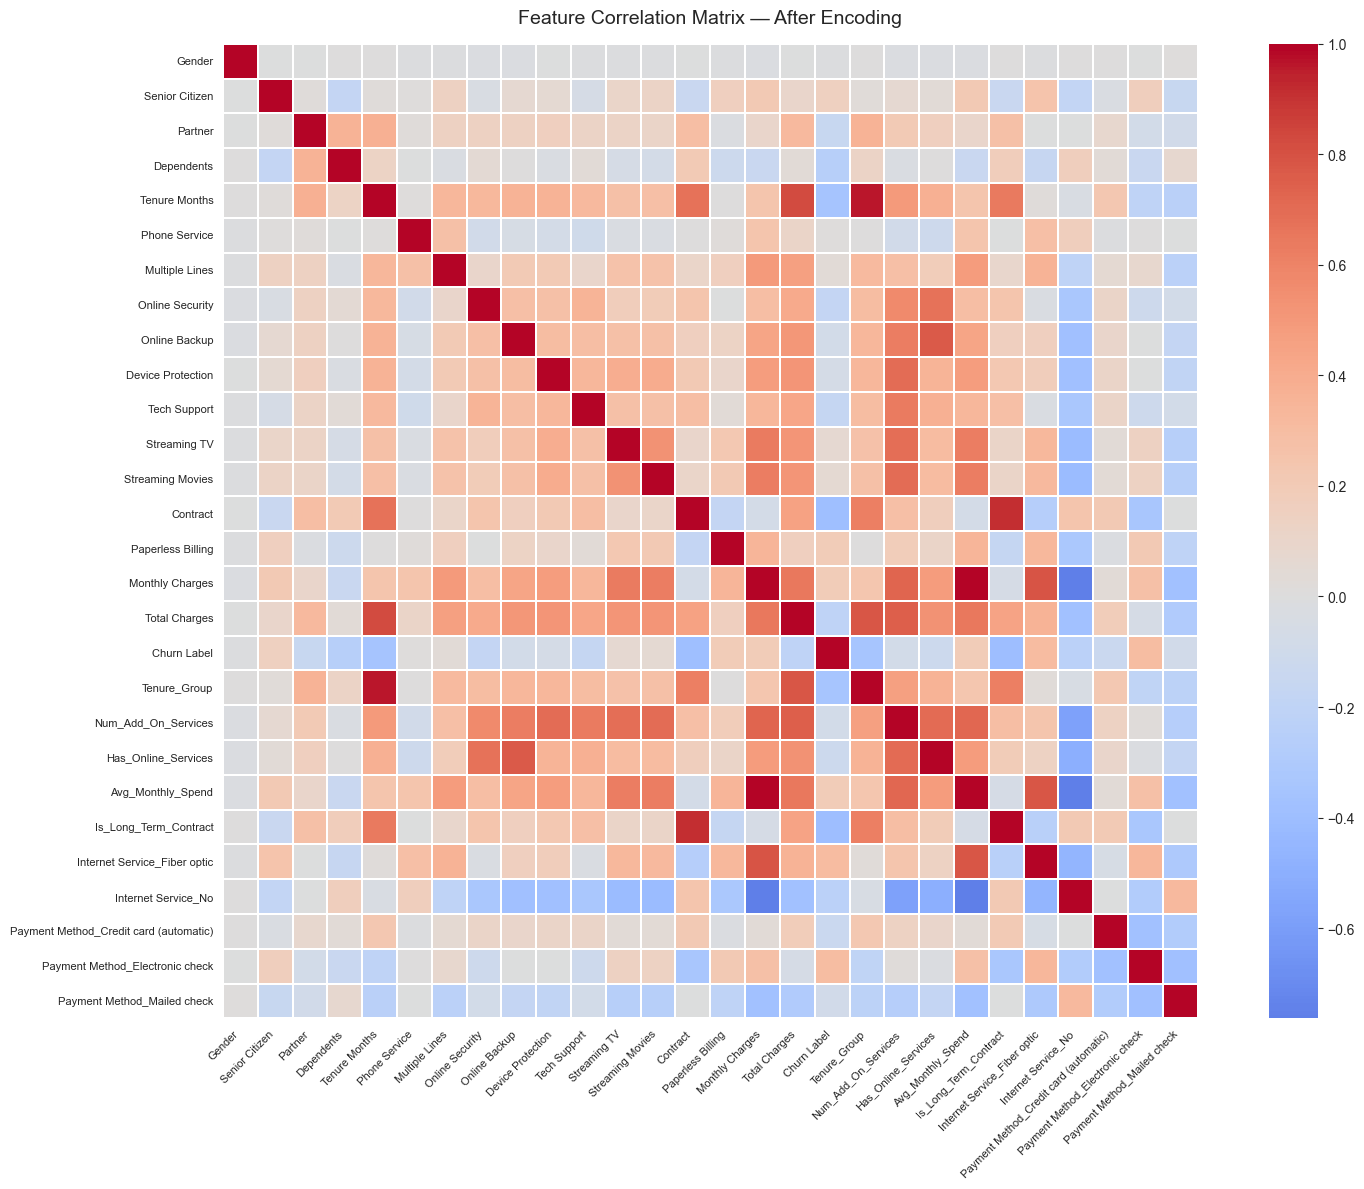

=== Correlation with Churn Label (top 15) ===
Is_Long_Term_Contract              0.4051
Contract                           0.3967
Tenure Months                      0.3522
Tenure_Group                       0.3454
Internet Service_Fiber optic       0.3080
Payment Method_Electronic check    0.3019
Dependents                         0.2485
Internet Service_No                0.2279
Total Charges                      0.1995
Monthly Charges                    0.1934
Avg_Monthly_Spend                  0.1925
Paperless Billing                  0.1918
Online Security                    0.1712
Tech Support                       0.1647
Senior Citizen                     0.1509

=== Highly correlated feature PAIRS (r > 0.75, excluding target) ===
  Tenure Months ↔ Total Charges: r = 0.826
  Tenure Months ↔ Tenure_Group: r = 0.961
  Online Backup ↔ Has_Online_Services: r = 0.768
  Contract ↔ Is_Long_Term_Contract: r = 0.916
  Monthly Charges ↔ Avg_Monthly_Spend: r = 0.996
  Monthly Charges ↔ Inter

In [23]:
plt.figure(figsize=(16, 12))
corr_matrix = df.corr()
mask = corr_matrix.abs() < 0.1  # hide very weak correlations for clarity
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    linewidths=0.3,
    square=True
)
plt.title("Feature Correlation Matrix — After Encoding", fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig(PLOTS_PATH / "01_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Print top correlations with target
print("=== Correlation with Churn Label (top 15) ===")
target_corr = corr_matrix[TARGET_COLUMN].drop(TARGET_COLUMN).abs().sort_values(ascending=False)
print(target_corr.round(4).head(15).to_string())

print("\n=== Highly correlated feature PAIRS (r > 0.75, excluding target) ===")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        c1 = corr_matrix.columns[i]
        c2 = corr_matrix.columns[j]
        if c1 == TARGET_COLUMN or c2 == TARGET_COLUMN:
            continue
        r = abs(corr_matrix.loc[c1, c2])
        if r > 0.75:
            print(f"  {c1} ↔ {c2}: r = {r:.3f}")

### 7.2 Feature Importance — Quick Random Forest
A lightweight Random Forest (100 trees, no tuning) tells us which features contribute most to predicting churn. This is NOT the final model — it is used only for feature ranking.

> **WARNING**: RandomForest feature importance may become unstable when highly correlated or derived features exist. Results are guidance only and NOT final feature selection.

Feature-ranking EDA uses 7032 complete rows; model pipelines handle preserved nulls after the split.


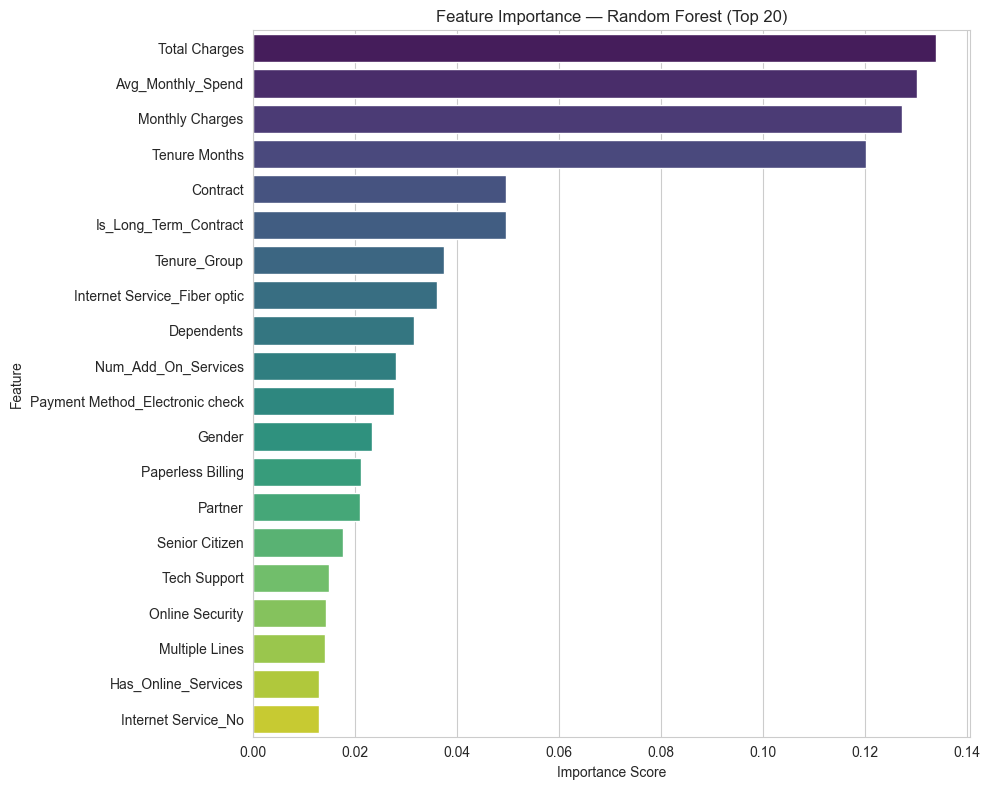

Top 20 Features by Importance:
                        Feature  Importance
                  Total Charges    0.133988
              Avg_Monthly_Spend    0.130209
                Monthly Charges    0.127338
                  Tenure Months    0.120207
                       Contract    0.049671
          Is_Long_Term_Contract    0.049612
                   Tenure_Group    0.037437
   Internet Service_Fiber optic    0.036023
                     Dependents    0.031593
            Num_Add_On_Services    0.028003
Payment Method_Electronic check    0.027593
                         Gender    0.023302
              Paperless Billing    0.021218
                        Partner    0.020928
                 Senior Citizen    0.017664
                   Tech Support    0.014868
                Online Security    0.014292
                 Multiple Lines    0.014117
            Has_Online_Services    0.012913
            Internet Service_No    0.012900


In [24]:
ranking_input = df.dropna(subset=['Total Charges'])
X = ranking_input.drop(columns=[TARGET_COLUMN])
y = ranking_input[TARGET_COLUMN]
print(f"Feature-ranking EDA uses {len(ranking_input)} complete rows; model pipelines handle preserved nulls after the split.")

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=1
)
rf.fit(X, y)

importance_df = pd.DataFrame({
    'Feature':    X.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

# Plot top 20
top20 = importance_df.head(20)
plt.figure(figsize=(10, 8))
sns.barplot(data=top20, x='Importance', y='Feature', palette='viridis')
plt.title("Feature Importance — Random Forest (Top 20)", fontsize=12)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "02_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 20 Features by Importance:")
print(top20.to_string(index=False))

### 7.3 Feature Recommendations
We combine statistical test results with correlation and importance scores to make final drop recommendations.

> **NOTE**: No features are physically dropped in Phase 2. Final selection occurs in Phase 3.

In [31]:
# Get correlation with target for all features
corr_with_target = df.corr()[TARGET_COLUMN].drop(TARGET_COLUMN).abs()

# Build feature ranking table
ranking_df = pd.DataFrame({
    'Feature':          X.columns,
    'Importance_RF':    rf.feature_importances_,
    'Corr_with_Target': corr_with_target.reindex(X.columns).values
}).sort_values('Importance_RF', ascending=False).reset_index(drop=True)

# Apply drop decision rules
def get_recommendation(row):
    feat = row['Feature']
    corr = row['Corr_with_Target']
    imp  = row['Importance_RF']
    # Low correlation AND low importance
    if corr < 0.05 and imp < 0.01:
        return 'DROP'
    # Multicollinearity: flag Total Charges
    if feat == 'Total Charges':
        return 'FLAG — highly correlated with Tenure Months (r=0.825)'
    # Is_Long_Term_Contract is derived from Contract — flag as redundant
    if feat == 'Is_Long_Term_Contract':
        return 'KEEP (or DROP if Contract is kept — redundant with Contract)'
    return 'KEEP'

ranking_df['Recommendation'] = ranking_df.apply(get_recommendation, axis=1)

print(" Feature Ranking & Recommendations ")
display(ranking_df)

print("\n DROP candidates ")
drops = ranking_df[ranking_df['Recommendation']=='DROP']['Feature'].tolist()
if drops:
    for f in drops:
        print(f"  → {f}")
else:
    print("  No features meet DROP criteria.")

# Export selected features
ranking_df.to_csv(SUMMARIES_PATH / "selected_features.csv", index=False, encoding='utf-8')
print(f"\nSaved: {SUMMARIES_PATH / 'selected_features.csv'}")

# makes the final call during model pipeline construction.
print("\nNOTE: Recommendations are guidance only.")
print("   Mohamed Mahmoud (Phase 3) decides final feature set during pipeline.")

 Feature Ranking & Recommendations 


,Feature,Importance_RF,Corr_with_Target,Recommendation
0,Total Charges,0.133988,0.199484,FLAG — highly correlated with Tenure Months (r...
1,Avg_Monthly_Spend,0.130209,0.192530,KEEP
2,Monthly Charges,0.127338,0.193356,KEEP
3,Tenure Months,0.120207,0.352229,KEEP
4,Contract,0.049671,0.396713,KEEP
5,Is_Long_Term_Contract,0.049612,0.405103,KEEP (or DROP if Contract is kept — redundant ...
6,Tenure_Group,0.037437,0.345410,KEEP
7,Internet Service_Fiber optic,0.036023,0.308020,KEEP
8,Dependents,0.031593,0.248542,KEEP
9,Num_Add_On_Services,0.028003,0.087698,KEEP



 DROP candidates 
  → Phone Service

Saved: c:\Users\momoh\Downloads\Customer-Churn-Prediction-and-Analysis-Project-main\data\summaries\selected_features.csv

NOTE: Recommendations are guidance only.
   Mohamed Mahmoud (Phase 3) decides final feature set during pipeline.


### GATE 3 — Pre-Export Validation
_All checks must PASS before processed_telco.csv is saved._

In [26]:
gate3_pass = True

# CHECK 3.1 — Zero object dtype columns
obj_remaining = df.select_dtypes(include=['object']).columns.tolist()
if obj_remaining:
    print(f"GATE 3.1 FAIL: Object dtype columns remain: {obj_remaining}")
    gate3_pass = False
else:
    print("GATE 3.1 PASS: Zero object dtype columns.")

# CHECK 3.2 — Target column still intact
if TARGET_COLUMN in df.columns and set(df[TARGET_COLUMN].unique()).issubset({0, 1}):
    print(f"GATE 3.2 PASS: '{TARGET_COLUMN}' is binary 0/1.")
else:
    print(f"GATE 3.2 FAIL: Target column issue.")
    gate3_pass = False

# CHECK 3.3 — Only source Total Charges nulls may remain for pipeline imputation
null_counts = df.isnull().sum()
unexpected_nulls = null_counts[(null_counts > 0) & (null_counts.index != 'Total Charges')]
if unexpected_nulls.empty:
    print(f"GATE 3.3 PASS: Only {int(null_counts['Total Charges'])} expected Total Charges nulls remain.")
else:
    print(f"GATE 3.3 FAIL: Unexpected nulls present: {unexpected_nulls.to_dict()}.")
    gate3_pass = False

# CHECK 3.4 — All 5 engineered features present
new_features = [
    'Tenure_Group', 'Num_Add_On_Services',
    'Has_Online_Services', 'Avg_Monthly_Spend', 'Is_Long_Term_Contract'
]
missing_feats = [f for f in new_features if f not in df.columns]
if not missing_feats:
    print(f"GATE 3.4 PASS: All 5 engineered features present.")
else:
    print(f"GATE 3.4 FAIL: Missing features: {missing_feats}")
    gate3_pass = False

# CHECK 3.5 — Row count unchanged
if len(df) == EXPECTED_INPUT_ROWS:
    print(f"GATE 3.5 PASS: Row count unchanged — {len(df)} rows.")
else:
    print(f"GATE 3.5 FAIL: Row count changed to {len(df)}. Expected {EXPECTED_INPUT_ROWS}.")
    gate3_pass = False

if not gate3_pass:
    raise ValueError("GATE 3 FAILED. Fix issues above before exporting.")
else:
    print(f"\nGATE 3 COMPLETE — Safe to export.")
    print(f"   Final shape: {df.shape}")
    print(f"   Columns: {len(df.columns)}")

GATE 3.1 PASS: Zero object dtype columns.
GATE 3.2 PASS: 'Churn Label' is binary 0/1.
GATE 3.3 PASS: Only 11 expected Total Charges nulls remain.
GATE 3.4 PASS: All 5 engineered features present.
GATE 3.5 PASS: Row count unchanged — 7043 rows.

GATE 3 COMPLETE — Safe to export.
   Final shape: (7043, 28)
   Columns: 28


## 8. Export Processed Dataset

In [27]:
# Ensure Churn Label is the last column
cols = [c for c in df.columns if c != TARGET_COLUMN] + [TARGET_COLUMN]
df = df[cols]

backup_if_overwriting(PROCESSED_DATA_PATH, PROJECT_ROOT, "processed dataset")
df.to_csv(PROCESSED_DATA_PATH, index=False, encoding='utf-8')
print(f"   Exported: {PROCESSED_DATA_PATH}")
print(f"   Rows:    {len(df)}")
print(f"   Columns: {len(df.columns)}")
print(f"   Encoding: UTF-8")
print(f"   Target distribution:\n{df[TARGET_COLUMN].value_counts()}")
print(f"\nColumn list:")
for i, c in enumerate(df.columns, 1):
    print(f"   {i:2d}. {c}: {df[c].dtype}")
record_regeneration_step(
    PROJECT_ROOT,
    "02_feature_engineering",
    "notebooks/02_mohy_feature_engineering.ipynb",
    [PROCESSED_DATA_PATH],
)


   Exported: c:\Users\momoh\Downloads\Customer-Churn-Prediction-and-Analysis-Project-main\data\cleaned\processed_telco.csv
   Rows:    7043
   Columns: 28
   Encoding: UTF-8
   Target distribution:
Churn Label
0    5174
1    1869
Name: count, dtype: int64

Column list:
    1. Gender: int64
    2. Senior Citizen: int64
    3. Partner: int64
    4. Dependents: int64
    5. Tenure Months: int64
    6. Phone Service: int64
    7. Multiple Lines: int64
    8. Online Security: int64
    9. Online Backup: int64
   10. Device Protection: int64
   11. Tech Support: int64
   12. Streaming TV: int64
   13. Streaming Movies: int64
   14. Contract: int64
   15. Paperless Billing: int64
   16. Monthly Charges: float64
   17. Total Charges: float64
   18. Tenure_Group: int64
   19. Num_Add_On_Services: int64
   20. Has_Online_Services: int64
   21. Avg_Monthly_Spend: float64
   22. Is_Long_Term_Contract: int64
   23. Internet Service_Fiber optic: int64
   24. Internet Service_No: int64
   25. Payment

### GATE 4 — Export Validation
_Reads file back from disk and confirms correctness._

In [29]:
df_check = pd.read_csv(PROCESSED_DATA_PATH)
errors = []

if len(df_check) != EXPECTED_INPUT_ROWS:
    errors.append(f"GATE 4.1 FAIL: Row count {len(df_check)} ≠ {EXPECTED_INPUT_ROWS}")
else:
    print(f"GATE 4.1 PASS: {len(df_check)} rows confirmed.")

if TARGET_COLUMN not in df_check.columns:
    errors.append(f" GATE 4.2 FAIL: '{TARGET_COLUMN}' missing.")
else:
    print(f"GATE 4.2 PASS: '{TARGET_COLUMN}' present.")

obj_cols = df_check.select_dtypes(include=['object']).columns.tolist()
if obj_cols:
    errors.append(f"GATE 4.3 FAIL: Object dtype columns in file: {obj_cols}")
else:
    print(f"GATE 4.3 PASS: Zero object dtype columns in exported file.")

null_counts = df_check.isnull().sum()
unexpected_nulls = null_counts[(null_counts > 0) & (null_counts.index != 'Total Charges')]
if not unexpected_nulls.empty:
    errors.append(f"GATE 4.4 FAIL: Unexpected nulls in exported file: {unexpected_nulls.to_dict()}.")
else:
    print(f"GATE 4.4 PASS: Only {int(null_counts['Total Charges'])} expected Total Charges nulls remain for pipeline imputation.")

leakage = ["Churn Score", "Churn Value", "Churn Reason", "CLTV"]
found_leak = [c for c in leakage if c in df_check.columns]
if found_leak:
    errors.append(f"GATE 4.5 FAIL: Leakage columns found: {found_leak}")
else:
    print(f"GATE 4.5 PASS: No leakage columns.")

if errors:
    for e in errors:
        print(e)
    raise ValueError("GATE 4 FAILED. Do NOT pass this file to Mohamed Mahmoud.")
else:
    print(f"\nGATE 4 COMPLETE — processed_telco.csv is valid and ready.")
    print(f"   Shape: {df_check.shape}")
    print(f" HANDOFF READY → 03_mahmoud_modeling_baseline.ipynb")

GATE 4.1 PASS: 7043 rows confirmed.
GATE 4.2 PASS: 'Churn Label' present.
GATE 4.3 PASS: Zero object dtype columns in exported file.
GATE 4.4 PASS: Only 11 expected Total Charges nulls remain for pipeline imputation.
GATE 4.5 PASS: No leakage columns.

GATE 4 COMPLETE — processed_telco.csv is valid and ready.
   Shape: (7043, 28)
 HANDOFF READY → 03_mahmoud_modeling_baseline.ipynb


## 9. Summary & Handoff

### What was accomplished in this notebook:
-  Validated input schema — 7,043 rows × 20 columns
-  Chi-Square tests: 14 of 16 categorical features are significant
-  Mann-Whitney U tests: all 3 numeric features are significant
-  Confirmed: Gender (p=0.487) and Phone Service (p=0.339) are NOT significant
-  Flagged: Tenure Months ↔ Total Charges multicollinearity (r=0.825)
-  Engineered 5 new features:
    - Tenure_Group: New / Early / Mid / Long lifecycle stage
    - Num_Add_On_Services: count of active add-on services (0–6)
    - Has_Online_Services: binary flag for online protection
    - Avg_Monthly_Spend: spend intensity per month
    - Is_Long_Term_Contract: binary flag for 1yr/2yr contracts
-  Encoded all categorical columns — zero object dtype columns remain
-  Generated correlation heatmap and feature importance plot
-  Exported: `data/cleaned/processed_telco.csv` (28 columns, fully numeric)
-  Exported: `data/summaries/statistical_tests.csv`
-  Exported: `data/summaries/selected_features.csv`
-  Exported: `data/summaries/feature_engineering_log.csv`

### Key Findings:
- **Strongest predictors**: Contract type, Internet Service (Fiber optic), Tenure Months, Payment Method (Electronic check), Dependents
- **Not significant**: Gender, Phone Service — flagged for potential removal
- **Multicollinearity**: Total Charges vs Tenure Months (r=0.825) — Mohamed Mahmoud should test both and keep the better performer
- **Engineered features that add signal**: Is_Long_Term_Contract (r=0.405), Tenure_Group (r=0.345), Num_Add_On_Services shows clear churn trend

### Notes for Mohamed Mahmoud (Phase 3):
- **processed_telco.csv** is fully numeric and ready for sklearn
- **Churn Label** is the last column (index position: final)
- **Total Charges** and **Tenure Months** are multicollinear — consider keeping only one in the final model or using Avg_Monthly_Spend
- **Is_Long_Term_Contract** is derived from **Contract** — they carry similar information. Test with and without to compare performance
- **Gender** and **Phone Service** had weak statistical significance — but keep them in processed_telco.csv and let RFE/model selection decide
- **selected_features.csv** contains full recommendations with reasoning

### Handoff to Mohamed Mahmoud:
**Read file:** `data/cleaned/processed_telco.csv`
**Notebook:** `03_mahmoud_modeling_baseline.ipynb`

Mohamed Mahmoud will perform:
- Train/test split (stratified, random_state=42)
- Logistic Regression (sklearn Pipeline)
- Random Forest (sklearn Pipeline)
- Evaluation: accuracy, precision, recall, F1, ROC-AUC
- Confusion matrix
- Model comparison report

> Do NOT modify `processed_telco.csv` after export.
> If re-running is needed, re-run this FULL notebook from CELL-01.

### Phase 2 MUST NOT:
- perform train/test split
- fit scalers
- perform balancing
- use SMOTE
- tune models
- optimize thresholds
- remove rows
- perform model evaluation